# 07 — Spatial Skill Maps

Per-cell skill (ACC, MSSS-vs-climatology) across Morocco for every (model, lead). Tells the regional-skill story: where does each model add value, and where does it underperform the baselines?

Inputs (controlled by `FILE_PREFIX`):
- `results/predictions/{prefix}pooled_allLeads.nc` — stitched OOS predictions + truth

Sections:
1. Setup + per-cell metric helpers.
2. Per-cell ACC maps — model × lead grid (anomaly-correlation skill).
3. Per-cell MSSS-vs-climatology maps — model × lead grid (skill score over climatology reference).
4. Difference maps — each ML model's per-cell ACC minus persistence ACC, at the headline lead.
5. Latitudinal skill profile — mean ACC by latitude band per model per lead.

Figures saved to `results/figures/07_spatial/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

from droughtmodel.utils import save_figure, RESULTS_DIR
from droughtmodel import data as ddata
from droughtmodel import features as dfeat

# Switch to '' when the production sweep finishes
FILE_PREFIX = ''
FIG_SUBDIR = '07_spatial'

PREDS_PATH = RESULTS_DIR / 'predictions' / f'{FILE_PREFIX}pooled_allLeads.nc'

MODEL_ORDER = ['climatology', 'persistence', 'ar', 'ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost']
BASELINE_NAMES = {'climatology', 'persistence', 'ar'}

ds_preds = xr.open_dataset(PREDS_PATH)
leads = sorted(int(L) for L in ds_preds['lead'].values)
models_present = [m for m in MODEL_ORDER if f'pred_{m}' in ds_preds.data_vars]

# Morocco mask via features.py for consistency with the pipeline
data_cfg = ddata.load_config(ROOT / 'configs' / 'data.yaml')
feat_cfg = dfeat.load_features_config(ROOT / 'configs' / 'features.yaml')
raw_datasets = ddata.load_all(data_cfg)
template = dfeat.gather_predictor('spei3', raw_datasets)
morocco_mask = dfeat.load_region_mask(feat_cfg['region_mask']['path'], template, name='morocco')

print(f'leads: {leads}')
print(f'models: {models_present}')
print(f'Morocco mask: {int(morocco_mask.sum())} cells')

/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


leads: [1, 3, 6]
models: ['climatology', 'persistence', 'ar', 'ols', 'ridge', 'lasso', 'elasticnet', 'rf', 'xgboost']
Morocco mask: 164 cells


In [2]:
def per_cell_acc(pred, truth, clim, winter_mask, mask):
    """Per-cell ACC = corr(pred-clim, truth-clim) over winter months."""
    yp, yt, yc = pred[winter_mask], truth[winter_mask], clim[winter_mask]
    pa, ta = yp - yc, yt - yc
    num = np.nanmean((pa - np.nanmean(pa, axis=0)) * (ta - np.nanmean(ta, axis=0)), axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        a = num / (np.nanstd(pa, axis=0) * np.nanstd(ta, axis=0))
    a[~mask.values] = np.nan
    return a

def per_cell_msss_vs_clim(pred, truth, clim, winter_mask, mask):
    """Per-cell MSSS = 1 - MSE(model) / MSE(climatology)."""
    yp, yt, yc = pred[winter_mask], truth[winter_mask], clim[winter_mask]
    mse_model = np.nanmean((yp - yt) ** 2, axis=0)
    mse_clim = np.nanmean((yc - yt) ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        s = 1.0 - mse_model / mse_clim
    s[~mask.values] = np.nan
    return s

time_idx = pd.DatetimeIndex(ds_preds['time'].values)
winter_mask = np.isin(time_idx.month, [11, 12, 1, 2])

# Compute per-cell skill for every (model, lead) once; cache for reuse below.
acc_grids = {}
msss_grids = {}
for L in leads:
    truth = ds_preds['truth'].sel(lead=L).values
    clim = ds_preds['pred_climatology'].sel(lead=L).values
    for mdl in models_present:
        pred = ds_preds[f'pred_{mdl}'].sel(lead=L).values
        acc_grids[(mdl, L)] = per_cell_acc(pred, truth, clim, winter_mask, morocco_mask)
        if mdl != 'climatology':                # climatology's MSSS-vs-clim is identically 0
            msss_grids[(mdl, L)] = per_cell_msss_vs_clim(pred, truth, clim, winter_mask, morocco_mask)

print('computed per-cell ACC for', len(acc_grids), '(model, lead) pairs')
print('computed per-cell MSSS-vs-clim for', len(msss_grids), 'pairs')

/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_94837/2219643573.py:5: RuntimeWarning: Mean of empty slice
  num = np.nanmean((pa - np.nanmean(pa, axis=0)) * (ta - np.nanmean(ta, axis=0)), axis=0)
/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_94837/2219643573.py:14: RuntimeWarning: Mean of empty slice
  mse_model = np.nanmean((yp - yt) ** 2, axis=0)
/var/folders/xn/v8sbk5z15kz4_5h963_9syrr0000gn/T/ipykernel_94837/2219643573.py:15: RuntimeWarning: Mean of empty slice
  mse_clim = np.nanmean((yc - yt) ** 2, axis=0)


computed per-cell ACC for 27 (model, lead) pairs
computed per-cell MSSS-vs-clim for 24 pairs


## 2. Per-cell ACC grid

Rows = model, columns = lead. Shared colorbar. Red = high ACC = the model tracks anomaly direction; blue = anti-correlated; white = no skill.

Climatology's ACC is `NaN` everywhere (zero-variance forecast) — climatology row is intentionally blank.

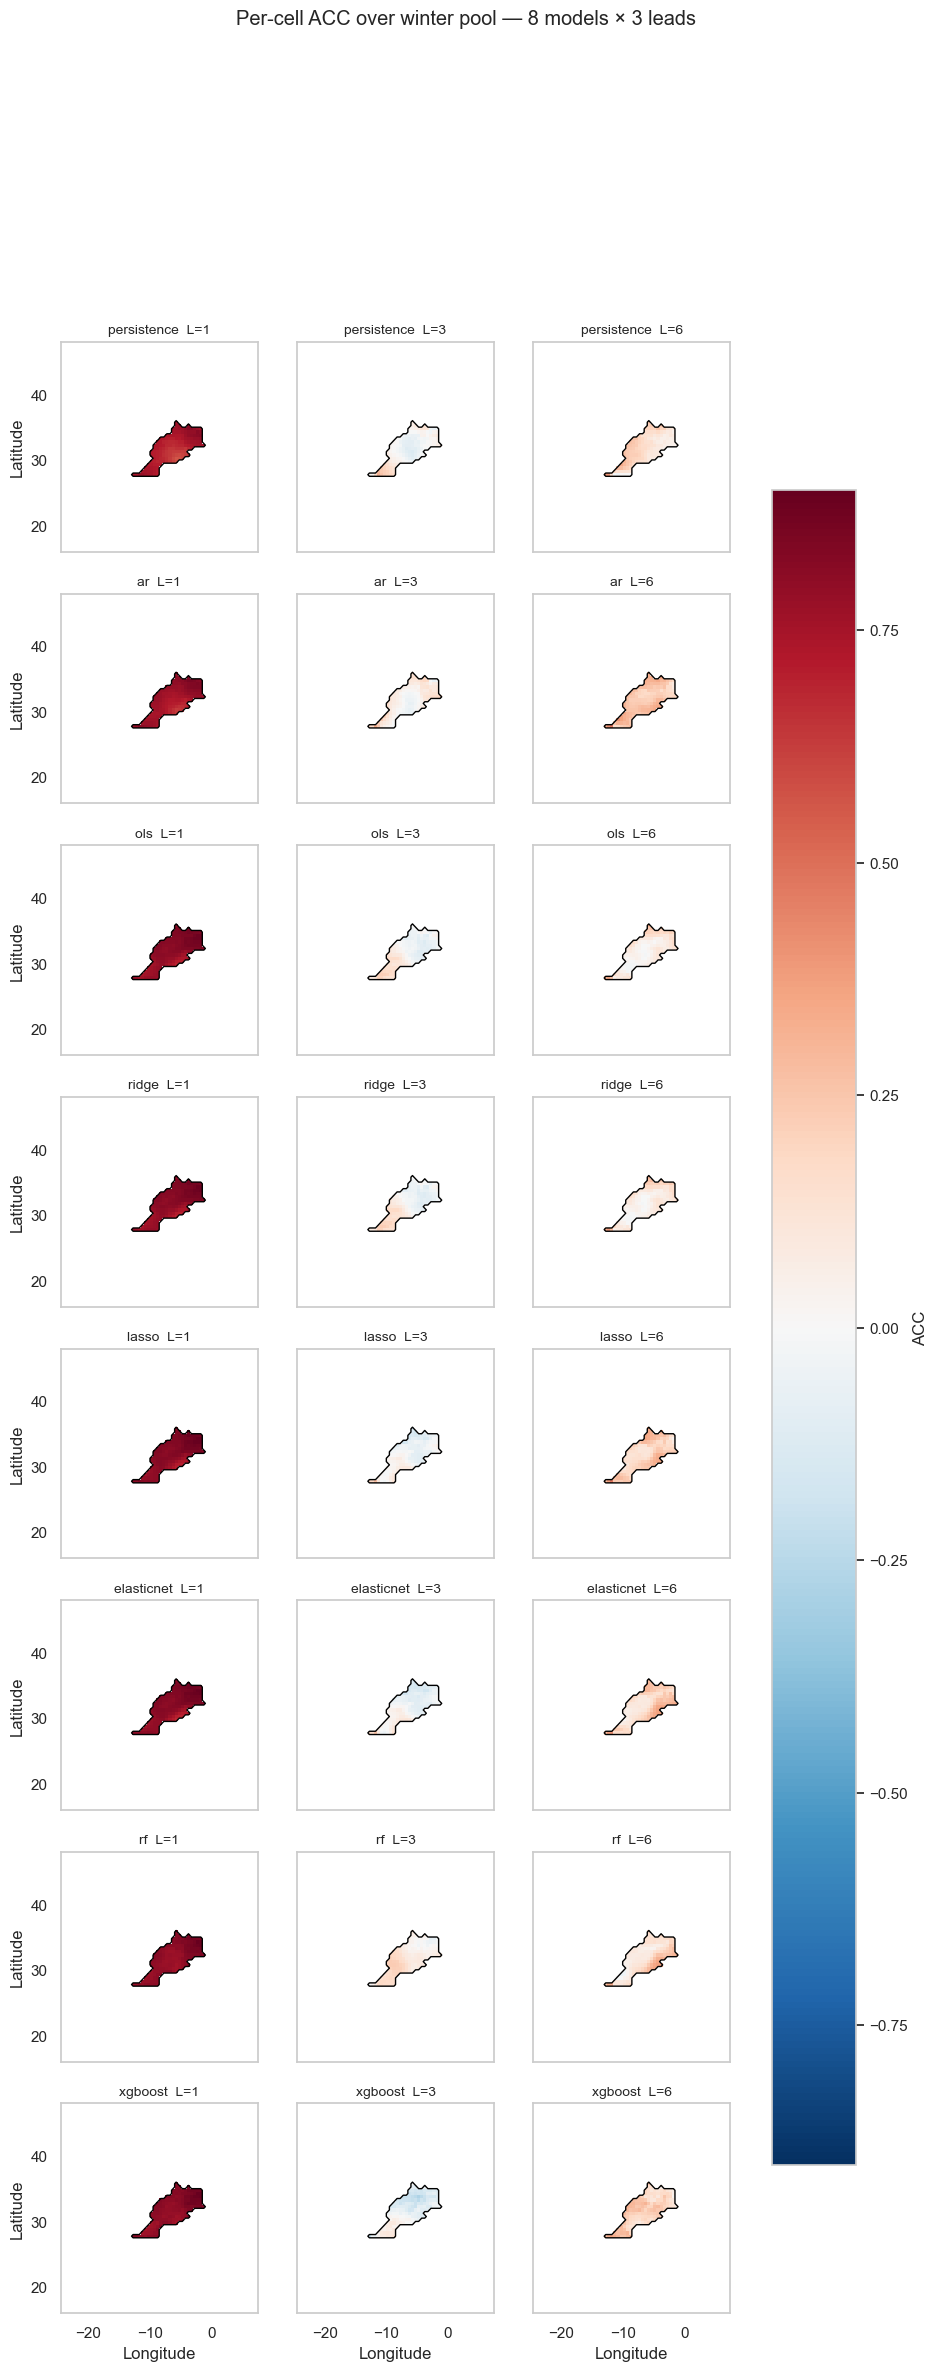


Morocco-mean per-cell ACC:


lead,1,3,6
model,,,
persistence,0.715,0.015,0.154
ar,0.765,0.060,0.254
ols,0.809,0.017,0.078
ridge,0.812,0.021,0.086
lasso,0.824,-0.023,0.209
elasticnet,0.819,-0.035,0.187
rf,0.810,0.095,0.145
xgboost,0.815,-0.077,0.204


In [3]:
lat = morocco_mask['lat']
lon = morocco_mask['lon']

# Skip climatology row in the ACC grid (NaN everywhere by construction)
acc_models = [m for m in models_present if m != 'climatology']
vmax = float(np.nanmax(np.abs([v for k, v in acc_grids.items() if k[0] != 'climatology']))) or 1.0

fig, axes = plt.subplots(
    len(acc_models), len(leads),
    figsize=(3.6 * len(leads), 3.2 * len(acc_models)),
    sharex=True, sharey=True,
)
if len(acc_models) == 1:
    axes = axes[np.newaxis, :]
im = None
for r, mdl in enumerate(acc_models):
    for c, L in enumerate(leads):
        ax = axes[r, c]
        da = xr.DataArray(acc_grids[(mdl, L)], dims=('lat', 'lon'), coords={'lat': lat, 'lon': lon})
        im = da.plot(ax=ax, cmap='RdBu_r', vmin=-vmax, vmax=vmax, add_colorbar=False)
        morocco_mask.plot.contour(ax=ax, levels=[0.5], colors='black', linewidths=1.0, add_colorbar=False)
        ax.set_title(f'{mdl}  L={L}', fontsize=10)
        ax.set_xlabel('Longitude' if r == len(acc_models) - 1 else '')
        ax.set_ylabel('Latitude' if c == 0 else '')

fig.colorbar(im, ax=axes.ravel().tolist(), label='ACC', shrink=0.85)
fig.suptitle(f'Per-cell ACC over winter pool — {len(acc_models)} models × {len(leads)} leads', y=1.01)
save_figure(fig, 'per_cell_acc_grid', subdir=FIG_SUBDIR)
plt.show()

summary = pd.DataFrame([
    {'model': mdl, 'lead': L, 'mean_acc': float(np.nanmean(acc_grids[(mdl, L)]))}
    for mdl in acc_models for L in leads
]).pivot(index='model', columns='lead', values='mean_acc').round(3).loc[acc_models]
print('\nMorocco-mean per-cell ACC:')
summary

## 3. Per-cell MSSS-vs-climatology grid

How much MSE improvement does each model give over climatology, per cell? Positive (red) = beats climatology; negative (blue) = worse than climatology. Climatology row is omitted (identically zero by construction).

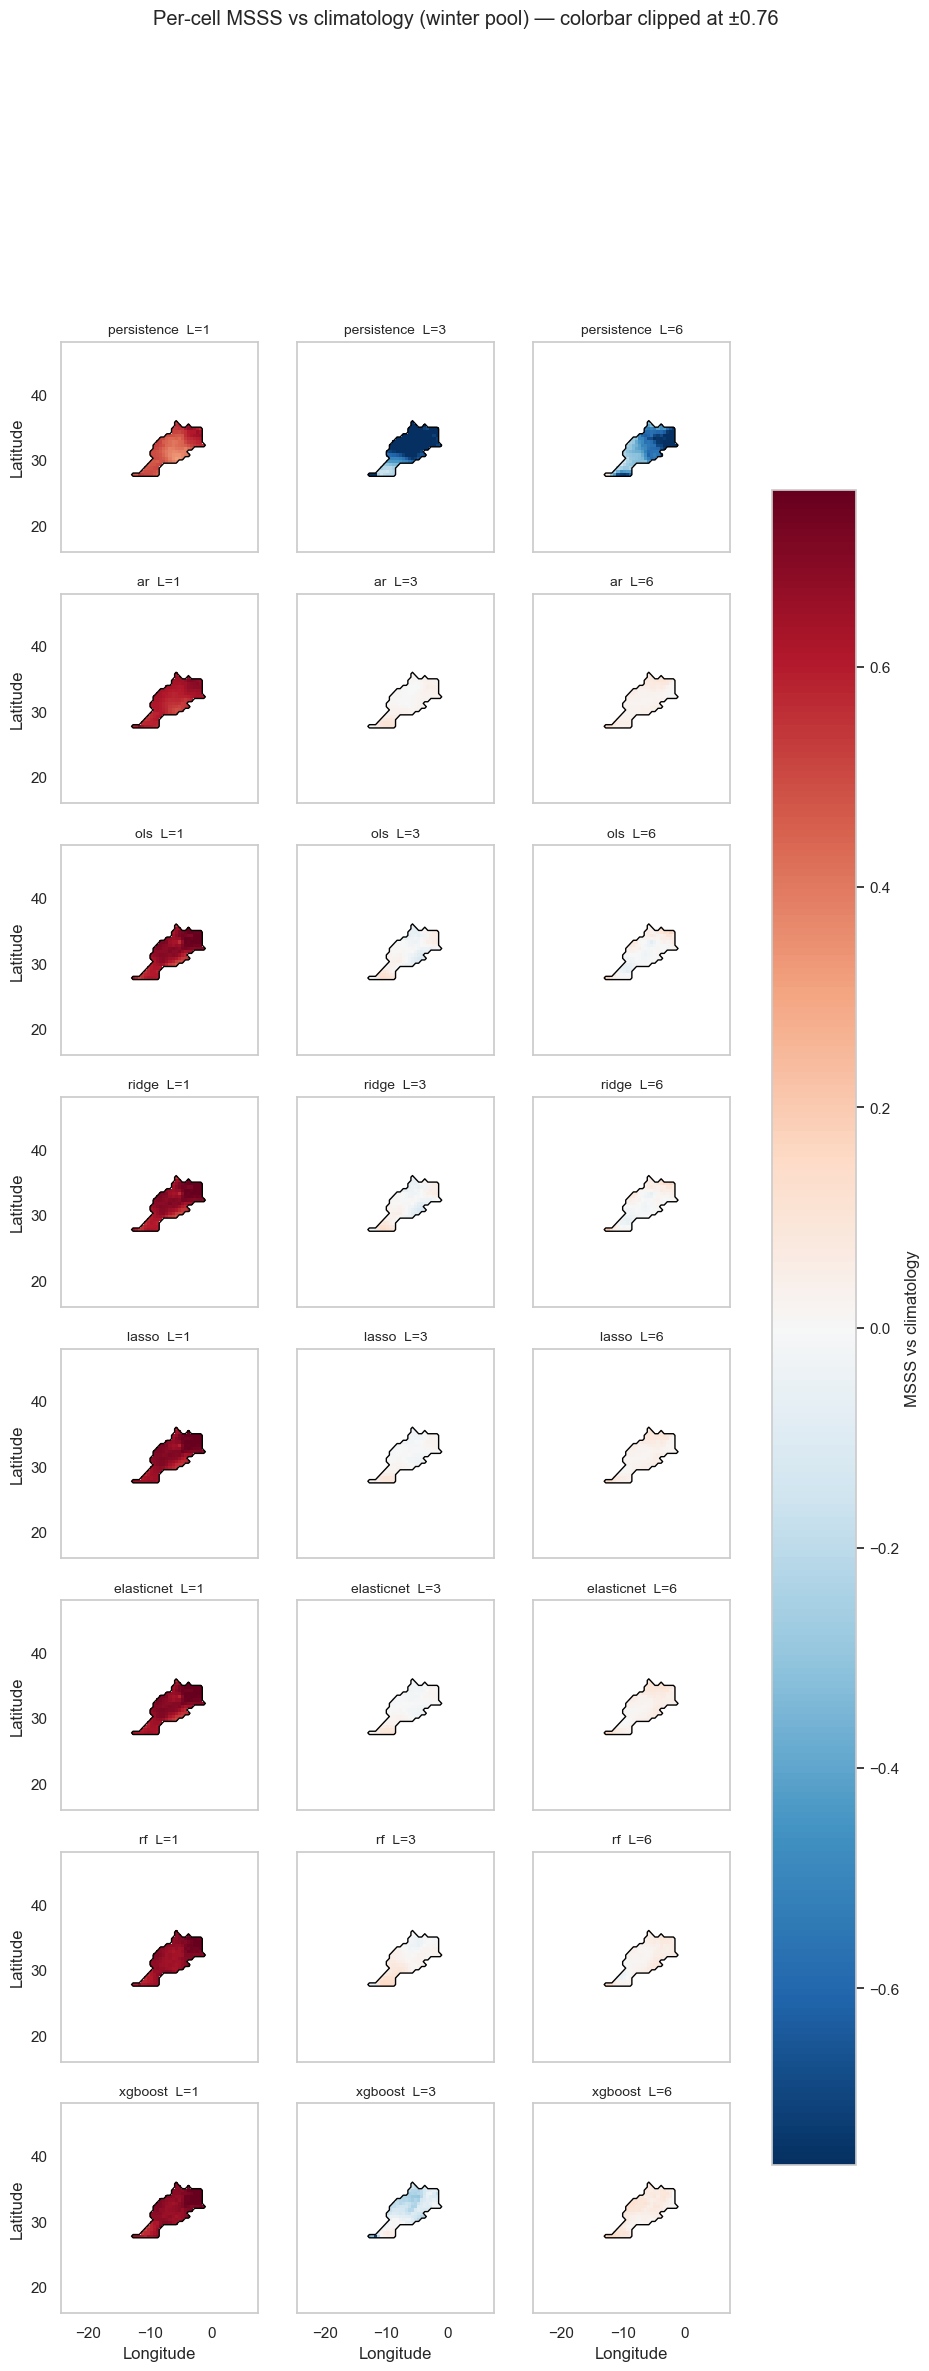


Morocco-mean per-cell MSSS-vs-climatology:


lead,1,3,6
model,,,
persistence,0.486,-0.761,-0.511
ar,0.605,0.027,0.041
ols,0.665,-0.001,0.012
ridge,0.668,0.001,0.015
lasso,0.687,0.005,0.041
elasticnet,0.679,0.005,0.047
rf,0.675,0.031,0.038
xgboost,0.684,-0.123,0.066


In [4]:
msss_models = [m for m in models_present if m != 'climatology']

# Cap colorbar at a sensible range — MSSS can blow up where MSE_clim is tiny
all_msss = np.concatenate([msss_grids[(m, L)].ravel() for m in msss_models for L in leads])
p95 = float(np.nanpercentile(np.abs(all_msss), 95)) or 1.0
vmax = min(p95, 1.0)

fig, axes = plt.subplots(
    len(msss_models), len(leads),
    figsize=(3.6 * len(leads), 3.2 * len(msss_models)),
    sharex=True, sharey=True,
)
if len(msss_models) == 1:
    axes = axes[np.newaxis, :]
im = None
for r, mdl in enumerate(msss_models):
    for c, L in enumerate(leads):
        ax = axes[r, c]
        da = xr.DataArray(msss_grids[(mdl, L)], dims=('lat', 'lon'), coords={'lat': lat, 'lon': lon})
        im = da.plot(ax=ax, cmap='RdBu_r', vmin=-vmax, vmax=vmax, add_colorbar=False)
        morocco_mask.plot.contour(ax=ax, levels=[0.5], colors='black', linewidths=1.0, add_colorbar=False)
        ax.set_title(f'{mdl}  L={L}', fontsize=10)
        ax.set_xlabel('Longitude' if r == len(msss_models) - 1 else '')
        ax.set_ylabel('Latitude' if c == 0 else '')

fig.colorbar(im, ax=axes.ravel().tolist(), label='MSSS vs climatology', shrink=0.85)
fig.suptitle(f'Per-cell MSSS vs climatology (winter pool) — colorbar clipped at ±{vmax:.2f}', y=1.01)
save_figure(fig, 'per_cell_msss_grid', subdir=FIG_SUBDIR)
plt.show()

summary = pd.DataFrame([
    {'model': mdl, 'lead': L, 'mean_msss': float(np.nanmean(msss_grids[(mdl, L)]))}
    for mdl in msss_models for L in leads
]).pivot(index='model', columns='lead', values='mean_msss').round(3).loc[msss_models]
print('\nMorocco-mean per-cell MSSS-vs-climatology:')
summary

## 4. Difference maps — ML models minus persistence

Per-cell `ACC(ML model) − ACC(persistence)` at the headline lead (L=3). Red regions = the ML model adds skill over persistence; blue regions = persistence still wins.

This is the cleanest "where does ML add value?" diagnostic — it isolates the ML model's contribution beyond the simplest inertia benchmark.

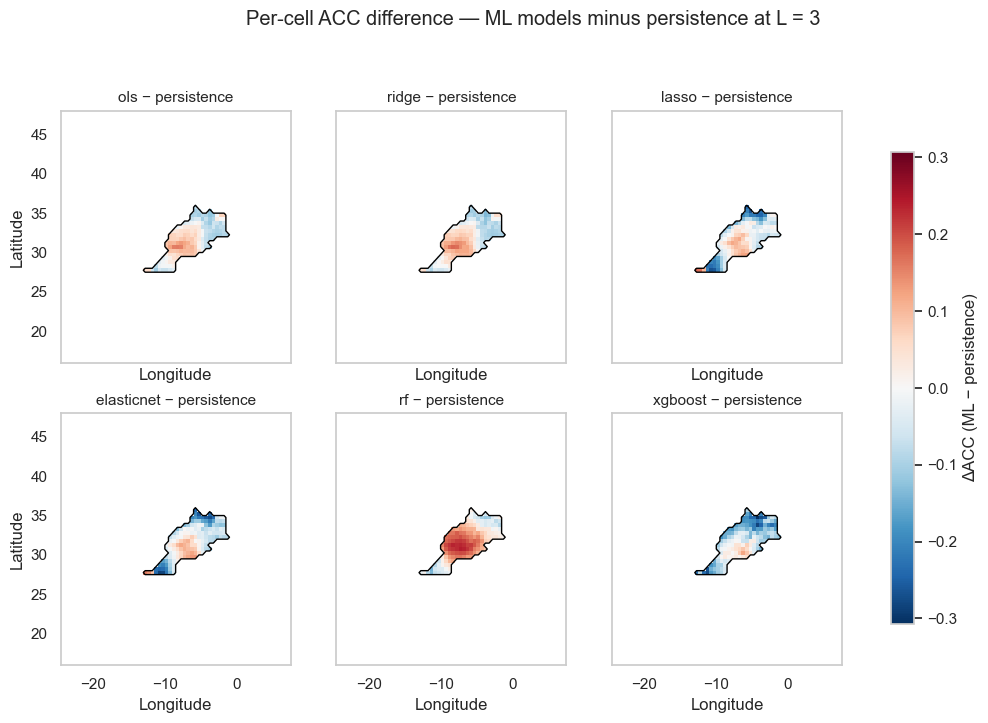


Morocco-mean ΔACC vs persistence at L= 3 :
  ols           mean = +0.002,  fraction-positive = 2.1%
  ridge         mean = +0.006,  fraction-positive = 2.1%
  lasso         mean = -0.038,  fraction-positive = 1.5%
  elasticnet    mean = -0.050,  fraction-positive = 1.2%
  rf            mean = +0.081,  fraction-positive = 3.0%
  xgboost       mean = -0.092,  fraction-positive = 0.8%


In [5]:
HEADLINE_LEAD = 3 if 3 in leads else leads[len(leads) // 2]
ml_models = [m for m in models_present if m not in BASELINE_NAMES]

if 'persistence' in models_present and ml_models:
    pers_acc = acc_grids[('persistence', HEADLINE_LEAD)]

    diff_grids = {mdl: acc_grids[(mdl, HEADLINE_LEAD)] - pers_acc for mdl in ml_models}
    vmax = float(np.nanmax(np.abs(list(diff_grids.values())))) or 0.1

    n_cols = min(3, len(ml_models))
    n_rows = (len(ml_models) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    im = None
    for i, mdl in enumerate(ml_models):
        ax = axes[i // n_cols, i % n_cols]
        da = xr.DataArray(diff_grids[mdl], dims=('lat', 'lon'), coords={'lat': lat, 'lon': lon})
        im = da.plot(ax=ax, cmap='RdBu_r', vmin=-vmax, vmax=vmax, add_colorbar=False)
        morocco_mask.plot.contour(ax=ax, levels=[0.5], colors='black', linewidths=1.0, add_colorbar=False)
        ax.set_title(f'{mdl} − persistence', fontsize=11)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude' if i % n_cols == 0 else '')
    # Hide any unused subplots
    for j in range(len(ml_models), n_rows * n_cols):
        axes[j // n_cols, j % n_cols].set_visible(False)

    fig.colorbar(im, ax=axes.ravel().tolist(), label='ΔACC (ML − persistence)', shrink=0.85)
    fig.suptitle(f'Per-cell ACC difference — ML models minus persistence at L = {HEADLINE_LEAD}', y=1.02)
    save_figure(fig, f'diff_acc_vs_persistence_L{HEADLINE_LEAD}', subdir=FIG_SUBDIR)
    plt.show()

    print('\nMorocco-mean ΔACC vs persistence at L=', HEADLINE_LEAD, ':')
    for mdl, d in diff_grids.items():
        print(f'  {mdl:12s}  mean = {float(np.nanmean(d)):+.3f},  fraction-positive = {float(np.nanmean(d > 0)):.1%}')
else:
    print('persistence or ML models absent; skipping difference maps')

## 5. Latitudinal skill profile

Morocco spans ~21° → 36° N (Sahara → Mediterranean). Skill is usually highest near the coast (NAO-influenced winter precip) and lower inland / south. This panel shows the **lead-by-lead** mean ACC by latitude band for the strongest models.

Bands are defined as latitude-quartiles of the Morocco-mask cells.

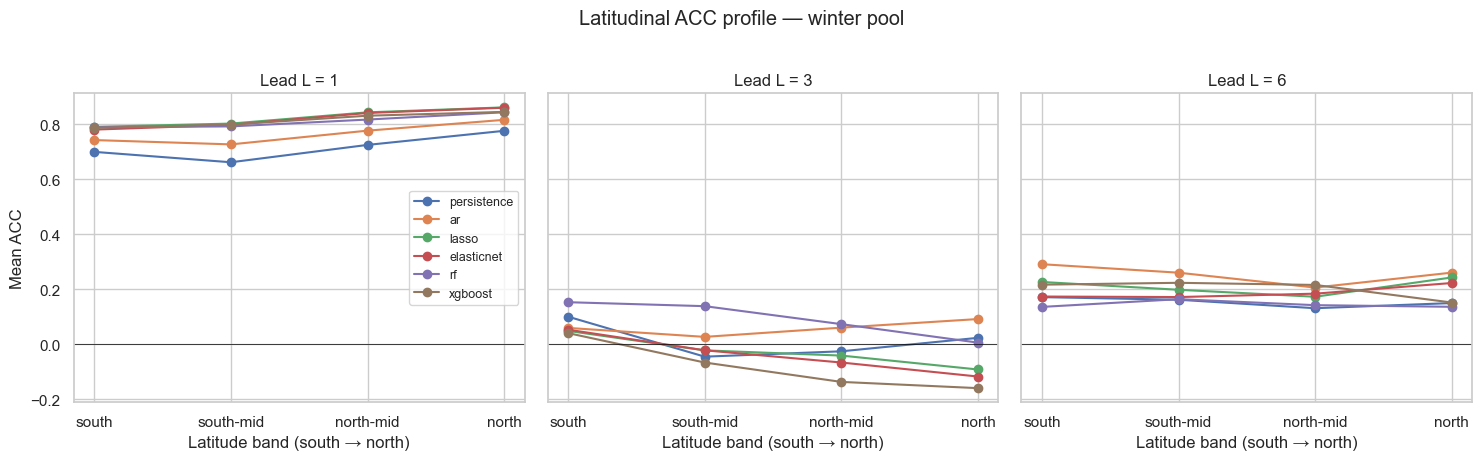

lead                       1      3      6
model       band                          
ar          north      0.817  0.092  0.261
            north-mid  0.777  0.061  0.207
            south      0.743  0.060  0.292
            south-mid  0.727  0.027  0.261
elasticnet  north      0.861 -0.117  0.223
            north-mid  0.842 -0.066  0.184
            south      0.781  0.053  0.174
            south-mid  0.798 -0.022  0.172
lasso       north      0.862 -0.091  0.243
            north-mid  0.844 -0.041  0.173
            south      0.791  0.049  0.227
            south-mid  0.803 -0.022  0.199
persistence north      0.777  0.024  0.150
            north-mid  0.725 -0.025  0.132
            south      0.700  0.101  0.172
            south-mid  0.662 -0.045  0.162
rf          north      0.844  0.006  0.137
            north-mid  0.818  0.074  0.143
            south      0.789  0.153  0.136
            south-mid  0.793  0.139  0.164
xgboost     north      0.846 -0.159  0.152
            north-mid  0.832 -0.136  0.216
            south      0.787  0.041  0.217
            south-mid  0.800 -0.066  0.224

In [6]:
# Build 4 latitude bands by quartile over the Morocco cells
lat_values = lat.values
lat_2d = np.broadcast_to(lat_values[:, None], morocco_mask.shape)
lat_in_mask = lat_2d[morocco_mask.values]
q1, q2, q3 = np.quantile(lat_in_mask, [0.25, 0.5, 0.75])
band_edges = [lat_in_mask.min() - 0.01, q1, q2, q3, lat_in_mask.max() + 0.01]
band_labels = ['south', 'south-mid', 'north-mid', 'north']

def assign_band(lat_grid):
    band = np.full(lat_grid.shape, -1, dtype=int)
    for i in range(4):
        band = np.where((lat_grid > band_edges[i]) & (lat_grid <= band_edges[i + 1]), i, band)
    return band

band_grid = assign_band(lat_2d)

# Show only the strongest few models to keep the figure readable
PROFILE_MODELS = [m for m in ['persistence', 'ar', 'lasso', 'elasticnet', 'rf', 'xgboost'] if m in models_present]

rows = []
for mdl in PROFILE_MODELS:
    for L in leads:
        grid = acc_grids[(mdl, L)]
        for b, label in enumerate(band_labels):
            cell_mask = (band_grid == b) & morocco_mask.values
            mean_acc = float(np.nanmean(grid[cell_mask]))
            rows.append({'model': mdl, 'lead': L, 'band': label, 'mean_acc': mean_acc})

profile = pd.DataFrame(rows)

fig, axes = plt.subplots(1, len(leads), figsize=(5 * len(leads), 4.5), sharey=True)
if len(leads) == 1:
    axes = [axes]
for ax, L in zip(axes, leads):
    sub = profile[profile['lead'] == L]
    for mdl in PROFILE_MODELS:
        d = sub[sub['model'] == mdl].set_index('band').reindex(band_labels)
        ax.plot(band_labels, d['mean_acc'], marker='o', linewidth=1.5, label=mdl)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'Lead L = {L}')
    ax.set_xlabel('Latitude band (south → north)')
    if L == leads[0]:
        ax.set_ylabel('Mean ACC')
        ax.legend(loc='best', fontsize=9)
fig.suptitle('Latitudinal ACC profile — winter pool', y=1.02)
plt.tight_layout()
save_figure(fig, 'latitudinal_acc_profile', subdir=FIG_SUBDIR)
plt.show()

profile_pivot = profile.pivot_table(index=['model', 'band'], columns='lead', values='mean_acc').round(3)
profile_pivot

## Notes

- All maps use the **winter target pool** (Nov-Feb only).
- The MSSS colorbar is clipped to the 95th percentile of `|MSSS|` so the cell-level extremes (where `MSE_clim` is tiny) don't wash out the rest of the plot.
- The latitudinal profile uses ACC quartile bands over the Morocco mask. For paper-quality regional grouping, swap in a hydroclimatic clustering (e.g. k-means on (mean precip, NAO sensitivity)) — that's a Phase 12 polish step.
- **Swap to production**: change `FILE_PREFIX = 'testOptuna_'` → `''` and re-run. All grids and difference maps regenerate against the production sweep automatically.